In [47]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Carregar os dados do MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target.astype(int)

In [48]:
# Função para aplicar PCA + K-Means e avaliar o modelo
def pca_kmeans(X, n_components, n_clusters):
    # Aplicar PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    # Aplicar K-Means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_pca)
    labels = kmeans.labels_

    # Calcular o Silhouette Score
    silhouette_avg = silhouette_score(X_pca, labels)

    return labels, silhouette_avg, X_pca


In [49]:
# Testar PCA + K-Means com 2, 10, e 30 componentes
components = [2, 10, 30]
n_clusters = 10  # Há 10 classes no dataset MNIST

# Armazenar resultados
results = {}

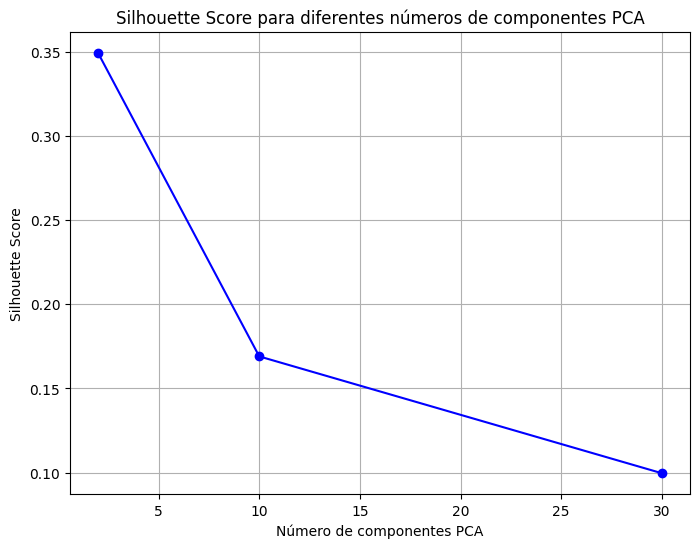

In [50]:
for n in components:
    labels, silhouette_avg, X_pca = pca_kmeans(X, n, n_clusters)
    results[n] = {'labels': labels, 'silhouette_score': silhouette_avg, 'pca': X_pca}

# Visualizar o Silhouette Score para os diferentes números de componentes
scores = [results[n]['silhouette_score'] for n in components]

# Plotar gráfico de Silhouette Score
plt.figure(figsize=(8, 6))
plt.plot(components, scores, marker='o', linestyle='-', color='b')
plt.title('Silhouette Score para diferentes números de componentes PCA')
plt.xlabel('Número de componentes PCA')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

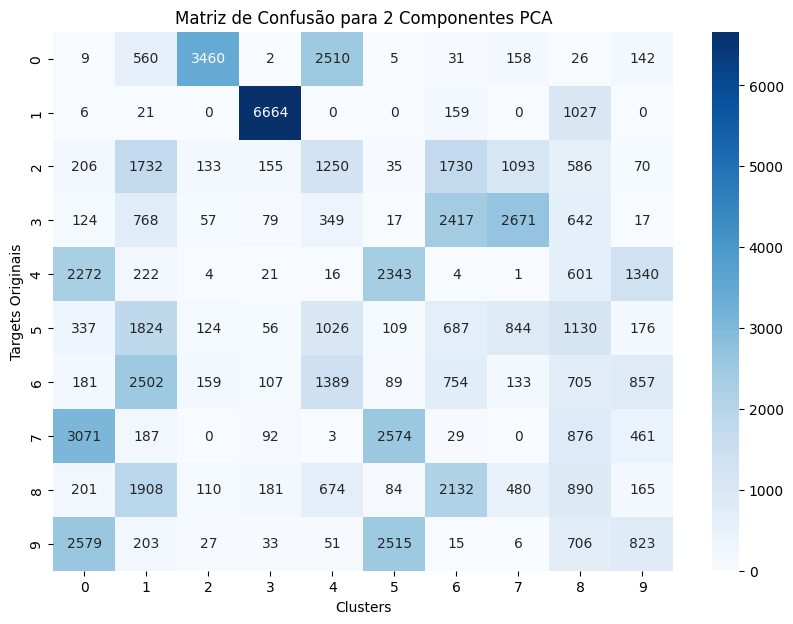

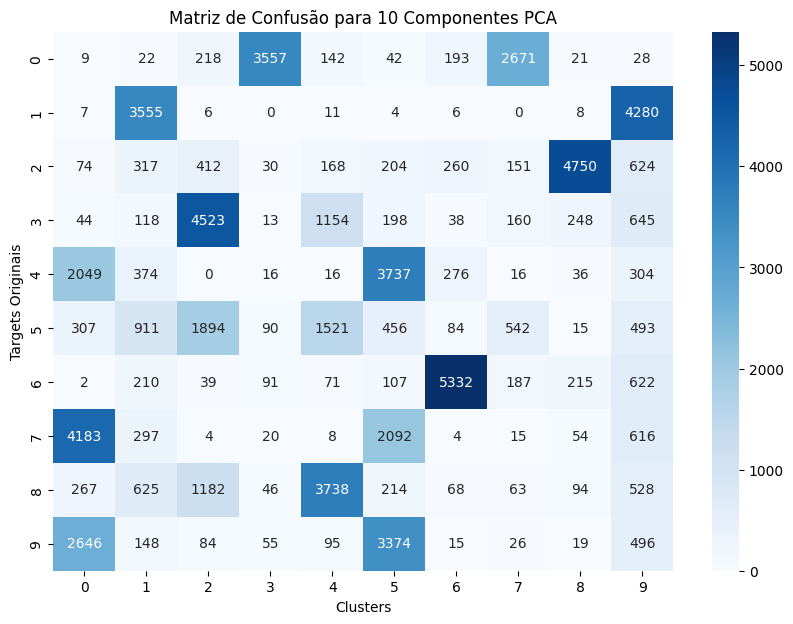

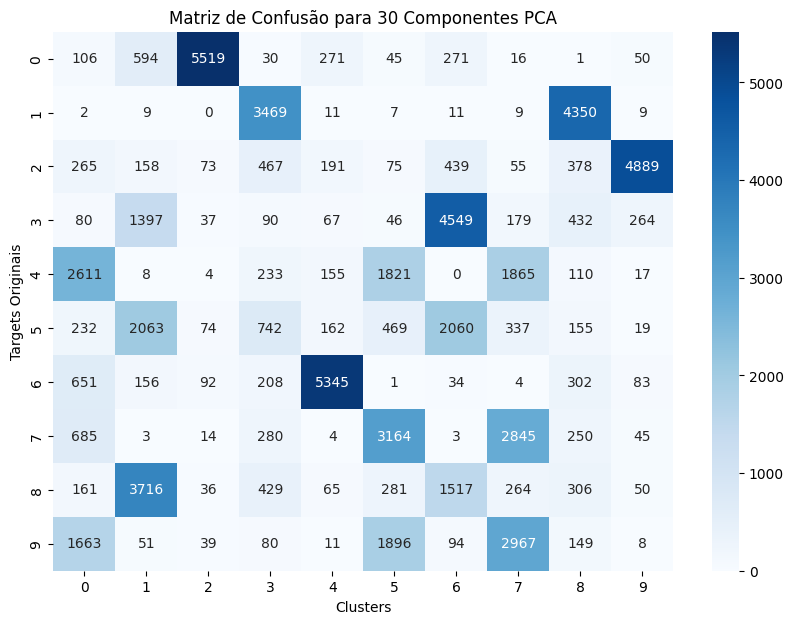

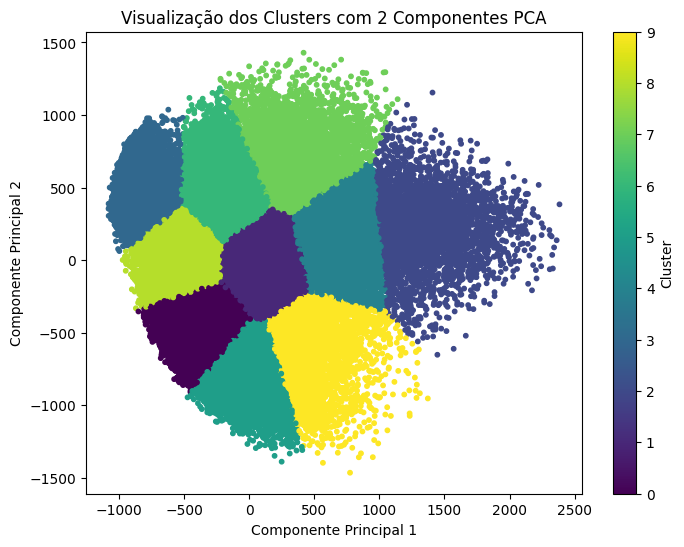

In [51]:
# Comparação com os targets originais
# Compração a distribuição dos clusters com os targets originais
for n in components:
    labels = results[n]['labels']
    # Criando uma matriz de confusão
    cm = confusion_matrix(y[:len(labels)], labels)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.title(f'Matriz de Confusão para {n} Componentes PCA')
    plt.xlabel('Clusters')
    plt.ylabel('Targets Originais')
    plt.show()

# Visualizar os clusters em 2D (com 2 componentes principais)
X_pca_2d = results[2]['pca']  # Usando 2 componentes principais
labels_2d = results[2]['labels']

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_2d, cmap='viridis', s=10)
plt.title('Visualização dos Clusters com 2 Componentes PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(label='Cluster')
plt.show()